# Extreme Learning Machine Model for WTI Direction Forecasting

This notebook trains Extreme Learning Machine (ELM) classifiers to predict the next-day direction of WTI crude oil prices. I compare several feature specifications: a baseline macro/price model, a CFTC/COT-augmented model, an HMM regime-feature model, and a regime-specific modeling approach.

An ELM is a single-hidden-layer neural network where the hidden-layer weights are randomly initialized and fixed. The output layer is then estimated using ridge regression. This makes ELM much faster to train than a standard neural network, while still allowing nonlinear transformations of the input features.

It's important to note that everything until the "Final Runs" are not included in the paper due to the dates changing based on COT data. I used the same tuned hyperparameters on the final runs that I found in the prelimary runs.

In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, ParameterGrid
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, balanced_accuracy_score
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
import os

## 2. Load Chronological Train, Validation, and Test Splits

The train, validation, and test files were created using chronological splits. This is necessary for a time-series forecasting problem because shuffling observations would allow future market conditions to influence earlier training observations.

I recompute log returns from WTI prices so the strategy evaluation uses a consistent realized-return series.

In [116]:
train_df = pd.read_csv("train_final.csv")
val_df = pd.read_csv("val_final.csv")
test_df = pd.read_csv("test_final.csv")

for df in [train_df, val_df, test_df]:
    df["returns"] = np.log(df["Price"]).diff()
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)

for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 3. Define Baseline Feature Set

The target variable is the next-day WTI direction. Non-predictive columns such as date, price, realized returns, and the target label are excluded from the feature matrix. Regime labels and regime probabilities are also excluded from the baseline model so it can be compared fairly against the later regime-enhanced specifications.

In [117]:
target_col = "Target"

baseline_exclude_cols = ["Date", "Price", "regime", "regime_prob_0", "regime_prob_1", "regime_prob_2", "returns", "Target"]

feature_cols = [c for c in train_df.columns if c not in baseline_exclude_cols]

X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

## 4. Extreme Learning Machine Model Wrapper

The ELM model is implemented as a single-hidden-layer neural network. Unlike a standard neural network, the hidden-layer weights and biases are randomly initialized and then fixed. The output layer is estimated using ridge regression.

The wrapper includes a standard scaler inside a scikit-learn pipeline so each ELM model is fit using standardized predictors. This is important because ELM hidden-layer activations are sensitive to input scale.

In [ ]:
class ELMClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        n_hidden=500,
        activation="tanh",
        alpha=1e-3,
        random_state=42,
        weight_init="orthogonal"
    ):
        self.n_hidden = n_hidden
        self.activation = activation
        self.alpha = alpha
        self.random_state = random_state
        self.weight_init = weight_init

    def _activation_function(self, X):
        if self.activation == "tanh":
            return np.tanh(X)
        elif self.activation == "relu":
            return np.maximum(0, X)
        elif self.activation == "sigmoid":
            return 1.0 / (1.0 + np.exp(-np.clip(X, -500, 500)))
        elif self.activation == "linear":
            return X
        else:
            raise ValueError("activation must be 'tanh', 'relu', 'sigmoid', or 'linear'")
  # different ways to initialize my weights
    def _make_W(self, n_features, n_hidden, rng):
        if self.weight_init == "normal":
            return rng.normal(size=(n_features, n_hidden))

        if self.weight_init == "uniform":
            return rng.uniform(-1, 1, size=(n_features, n_hidden))

        if self.weight_init == "xavier":
            limit = np.sqrt(6 / (n_features + n_hidden))
            return rng.uniform(-limit, limit, size=(n_features, n_hidden))

        if self.weight_init == "orthogonal":
            # Create an orthogonal basis, then resize to desired shape
            if n_features >= n_hidden:
                A = rng.normal(size=(n_features, n_hidden))
                Q, _ = np.linalg.qr(A)
                return Q[:, :n_hidden]
            else:
                A = rng.normal(size=(n_hidden, n_features))
                Q, _ = np.linalg.qr(A)
                return Q[:, :n_features].T

        raise ValueError("weight_init must be 'normal', 'uniform', 'xavier', or 'orthogonal'")

    def fit(self, X, y):
        """
        Trains the ELM model.

        Steps:
        1. Randomly initialize hidden layer weights W and biases b
        2. Compute hidden layer activations H
        3. Solve for output weights beta using ridge regression
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1, 1)

        rng = np.random.RandomState(self.random_state)
        n_features = X.shape[1]

        # W is the hidden-layer input weight matrix
        self.W_ = self._make_W(n_features, self.n_hidden, rng)
        # random biases
        self.b_ = rng.normal(size=(self.n_hidden,))


        H = self._activation_function(X @ self.W_ + self.b_)

        I = np.eye(self.n_hidden)
        self.beta_ = np.linalg.solve(
            H.T @ H + self.alpha * I,
            H.T @ y
        )

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        H = self._activation_function(X @ self.W_ + self.b_)
        scores = H @ self.beta_
        return scores.ravel()

    def predict_proba(self, X):
        scores = self.decision_function(X)
        probs_1 = 1.0 / (1.0 + np.exp(-np.clip(scores, -500, 500)))
        probs_0 = 1.0 - probs_1
        return np.column_stack([probs_0, probs_1])

    def predict(self, X):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= 0.5).astype(int)
    

class ELMModel:
    def __init__(
        self,
        n_hidden=500,
        activation="tanh",
        alpha=1e-3,
        threshold=0.5,
        random_state=42,
        weight_init="orthogonal"
    ):
        self.n_hidden = n_hidden
        self.activation = activation
        self.alpha = alpha
        self.threshold = threshold
        self.random_state = random_state
        self.weight_init = weight_init

        self.pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", ELMClassifier(
                n_hidden=self.n_hidden,
                activation=self.activation,
                alpha=self.alpha,
                random_state=self.random_state,
                weight_init=self.weight_init
            ))
        ])

    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self

    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)[:, 1]

    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= self.threshold).astype(int)

    def evaluate(self, X, y):
        y_pred = self.predict(X)
        y_prob = self.predict_proba(X)

        return {
            "accuracy": accuracy_score(y, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y, y_pred),
            "precision_down_0": precision_score(y, y_pred, pos_label=0, zero_division=0),
            "recall_down_0": recall_score(y, y_pred, pos_label=0, zero_division=0),
            "precision_up_1": precision_score(y, y_pred, pos_label=1, zero_division=0),
            "recall_up_1": recall_score(y, y_pred, pos_label=1, zero_division=0),
            "f1": f1_score(y, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y, y_prob),
            "confusion_matrix": confusion_matrix(y, y_pred),
            "classification_report": classification_report(y, y_pred, zero_division=0)
        }

## 5. Hyperparameter Tuning with Time-Series Cross-Validation

The ELM hyperparameters are tuned using `TimeSeriesSplit`, which preserves chronological order across folds. This is more appropriate than random cross-validation because the observations are time ordered.

The tuning grid compares the number of hidden units, activation function, ridge penalty, and hidden-weight initialization scheme. ROC-AUC is used as the tuning metric because the downstream trading strategy relies on predicted probabilities, not just hard class labels.

In [110]:
def tune_elm(X_train, y_train, n_splits=5):
    param_grid = {
        "n_hidden": [50, 100, 200, 300, 400, 500],
        "activation": ["tanh", "sigmoid", "relu"],
        "alpha": [1e-2, 1e-1, 1.0],
        "weight_init": ["orthogonal", "xavier", "normal"]
    }

    tscv = TimeSeriesSplit(n_splits=n_splits)

    best_score = -np.inf
    best_params = None
    all_results = []

    for params in ParameterGrid(param_grid):
        fold_scores = []

        for fold_train_idx, fold_val_idx in tscv.split(X_train):
            X_fold_train = X_train.iloc[fold_train_idx]
            y_fold_train = y_train.iloc[fold_train_idx]

            X_fold_val = X_train.iloc[fold_val_idx]
            y_fold_val = y_train.iloc[fold_val_idx]

            model = ELMModel(
                n_hidden=params["n_hidden"],
                activation=params["activation"],
                alpha=params["alpha"],
                threshold=0.5,
                random_state=42,
                weight_init=params["weight_init"]
            )
            model.fit(X_fold_train, y_fold_train)
            y_fold_val_prob = model.predict_proba(X_fold_val)

            try:
                score = roc_auc_score(y_fold_val, y_fold_val_prob)
            except ValueError:
                score = np.nan

            fold_scores.append(score)

        mean_score = np.nanmean(fold_scores)

        all_results.append({
            **params,
            "mean_cv_roc_auc": mean_score
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    results_df = pd.DataFrame(all_results).sort_values(
        by="mean_cv_roc_auc",
        ascending=False
    )

    return best_params, best_score, results_df

## 6. Tune the Baseline ELM

This cell searches over the ELM hyperparameter grid and selects the best baseline specification using time-series cross-validation.

In [138]:
best_params, best_cv_score, cv_results = tune_elm(X_train, y_train, n_splits=5)

print("Best params:", best_params)
print("Best CV ROC-AUC:", best_cv_score)

cv_results.head(10)

Best params: {'activation': 'tanh', 'alpha': 0.01, 'n_hidden': 100, 'weight_init': 'xavier'}
Best CV ROC-AUC: 0.5337427429924896


,activation,alpha,n_hidden,weight_init,mean_cv_roc_auc
4,tanh,0.01,100,xavier,0.533743
133,relu,0.10,200,xavier,0.530062
57,sigmoid,0.01,100,orthogonal,0.529035
21,tanh,0.10,100,orthogonal,0.528814
33,tanh,0.10,500,orthogonal,0.526648
111,relu,0.01,100,orthogonal,0.526199
139,relu,0.10,400,xavier,0.526039
39,tanh,1.00,100,orthogonal,0.525741
22,tanh,0.10,100,xavier,0.525545
24,tanh,0.10,200,orthogonal,0.524420


## 7. Fit the Baseline ELM

Although the tuning results are reported above, the final baseline configuration uses a ReLU activation with Xavier initialization because this produced a better predicted-probability distribution for the validation period. This matters because the trading strategy uses probability strength to size positions.

In [ ]:
elm_baseline_model = ELMModel(
    n_hidden=200,
    activation="relu",
    alpha=0.01,
    weight_init="xavier",
    threshold=0.5,
    random_state=42
)


elm_baseline_model.fit(X_train, y_train)

## 8. Generate Standard Prediction Outputs

This helper creates a consistent prediction dataframe for every ELM model version. It stores the predicted probability of an upward WTI move, the hard class prediction, the realized target, and the realized return. Keeping this format consistent makes the classification and trading-strategy evaluations reusable across model versions.

In [23]:
def make_prediction_output(df, X, y, model, model_name, version, split_name):
    out = df[["Date", "Price", "returns", "vol_20", "Target"]].copy()
    out["prob_up"] = model.predict_proba(X)
    out["pred"] = (out["prob_up"] >= 0.50).astype(int)
    out["model"] = model_name
    out["version"] = version
    out["split"] = split_name
    return out

The baseline ELM predictions are generated for the train, validation, and test periods and saved for later comparison.

In [24]:
os.makedirs("results/predictions", exist_ok=True)

elm_train_preds = make_prediction_output(
    train_df, X_train, y_train, elm_baseline_model,
    "elm", "baseline", "train"
)

elm_val_preds = make_prediction_output(
    val_df, X_val, y_val, elm_baseline_model,
    "elm", "baseline", "val"
)

elm_test_preds = make_prediction_output(
    test_df, X_test, y_test, elm_baseline_model,
    "elm", "baseline", "test"
)

elm_train_preds.to_csv("results/predictions/elm_baseline_train_predictions.csv", index=False)
elm_val_preds.to_csv("results/predictions/elm_baseline_val_predictions.csv", index=False)
elm_test_preds.to_csv("results/predictions/elm_baseline_test_predictions.csv", index=False)

The summary below checks the distribution of validation-set predicted probabilities. This is especially important for ELM because different random hidden-layer mappings can produce very different probability spreads.

In [25]:
elm_val_preds.head()
elm_val_preds[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.755406,0.903409,0.530303,-0.000103,0.024159
std,0.208692,0.295680,0.499554,0.025630,0.008671
min,0.083327,0.000000,0.000000,-0.134360,0.008609
25%,0.654572,1.000000,0.000000,-0.015055,0.018637
50%,0.775838,1.000000,1.000000,0.001782,0.022686
75%,0.940592,1.000000,1.000000,0.016680,0.027254
max,0.996914,1.000000,1.000000,0.082612,0.055159


The histogram below shows the distribution of predicted upward-move probabilities on the validation set. A useful probability model should not assign nearly identical probabilities to every observation.

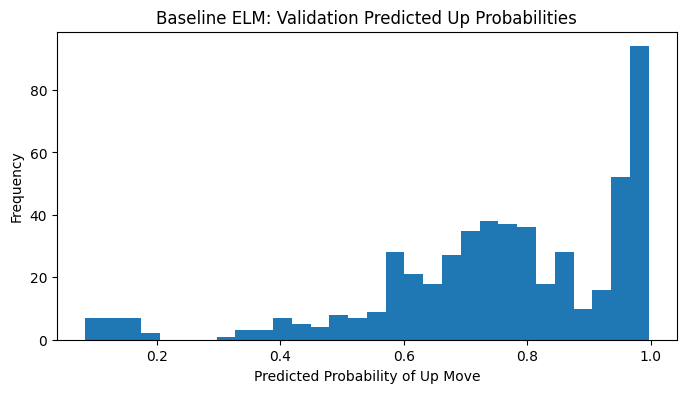

In [173]:
y_val_prob = elm_baseline_model.predict_proba(X_val)

plt.figure(figsize=(8, 4))
plt.hist(y_val_prob, bins=30)
plt.title("Baseline ELM: Validation Predicted Up Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Frequency")
plt.show()

## 9. Baseline Classification Evaluation

The classification metrics evaluate directional forecasting performance. Accuracy measures the overall fraction of correct up/down predictions, precision measures how often predicted up moves were correct, recall measures how many actual up moves were captured, F1 balances precision and recall, and ROC-AUC evaluates the ranking quality of predicted probabilities.

In [30]:
def classification_report_simple(preds):
    y_true = preds["Target"]
    y_pred = preds["pred"]
    prob = preds["prob_up"]

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }

classification_report_simple(elm_val_preds)

{'accuracy': 0.5208333333333334,
 'precision': 0.5283018867924528,
 'recall': 0.9,
 'f1': 0.665785997357992,
 'roc_auc': 0.5043778801843318,
 'confusion_matrix': array([[ 23, 225],
        [ 28, 252]], dtype=int64)}

## 10. Convert ELM Probabilities into Trading Positions

This function translates predicted probabilities into daily trading positions. Probabilities above 0.50 create long exposure and probabilities below 0.50 create short exposure. The position is volatility-scaled using rolling 20-day volatility and clipped between -1 and 1.

Strategy returns use the previous day's position multiplied by the current day's realized return, which avoids look-ahead bias. This is once again the basic trading strategy that basically serves as a placeholder until the final run. It's still an interesting comparison to see how trading performs given a larger dataset and basic trading parameters.

In [31]:
def apply_probability_vol_strategy(
    preds,
    target_annual_vol=0.15,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=1.0,
    beta=1.0,
    gamma=1.0
):
    df = preds.copy()

    raw_signal = 2.5 * df["prob_up"] - 1

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)

    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-1, 1)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = df["gross_strategy_return"] - transaction_cost * df["turnover"]

    df["buy_hold_return"] = df["returns"]

    return df

elm_val_strategy = apply_probability_vol_strategy(elm_val_preds)

## 11. Baseline Strategy Evaluation

The strategy metrics compare the ELM-driven validation strategy against a buy-and-hold benchmark. Total return and CAGR measure growth, annualized volatility measures risk, Sharpe ratio measures risk-adjusted performance, and maximum drawdown captures downside risk.

In [177]:
def max_drawdown(cum_returns):
    running_max = cum_returns.cummax()
    drawdown = cum_returns / running_max - 1
    return drawdown.min()

def strategy_metrics(df, return_col):
    data = df.dropna(subset=[return_col]).copy()
    ret = data[return_col]

    cumulative = (1 + ret).cumprod()
    total_return = cumulative.iloc[-1] - 1
    cagr = cumulative.iloc[-1] ** (252 / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = cagr / ann_vol if ann_vol != 0 else np.nan
    mdd = max_drawdown(cumulative)

    if return_col == "buy_hold_return":
        avg_position = 1.0
        avg_abs_position = 1.0
        avg_turnover = 0.0
    else:
        avg_position = df["position"].mean()
        avg_abs_position = df["position"].abs().mean()
        avg_turnover = df["turnover"].mean()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd,
        "Avg Position": avg_position,
        "Avg Abs Position": avg_abs_position,
        "Avg Turnover": avg_turnover,
    }

metrics = pd.DataFrame({
    "ELM Strategy Val": strategy_metrics(elm_val_strategy, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(elm_val_strategy, "buy_hold_return")
}).T

metrics 

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Strategy Val,0.071982,0.033796,0.160598,0.210440,-0.181644,0.370835,0.393763,0.042851
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000


The cumulative-growth plot compares validation-period performance of the baseline ELM strategy against buy-and-hold. This shows whether the model's directional probabilities translate into economic value.

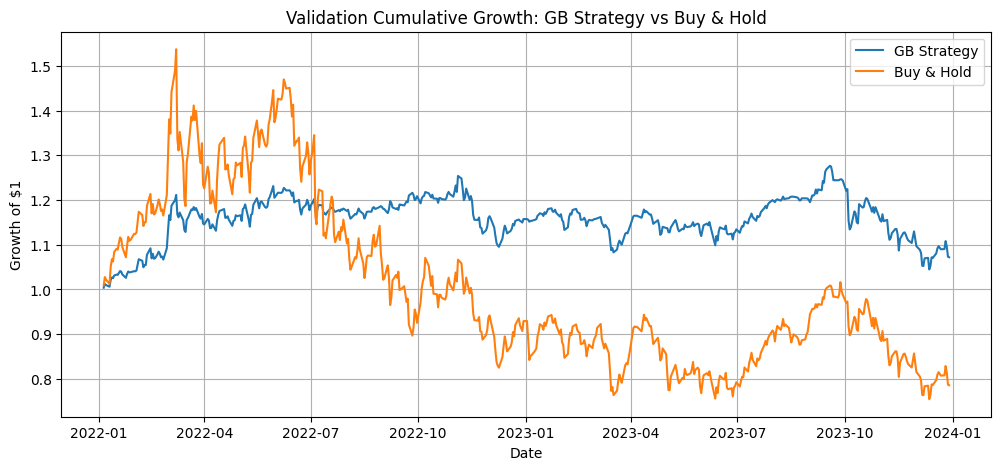

In [ ]:
plot_df = elm_val_strategy.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="GB Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: GB Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()


## 12. Probability Calibration Check

To understand whether higher ELM predicted probabilities correspond to stronger realized outcomes, I group validation predictions into probability buckets and compare average predicted probability, realized upward-move frequency, and average return.

In [ ]:
val_bucket = elm_val_preds.copy()

val_bucket["bucket"] = pd.cut(val_bucket["prob_up"], bins=10)

bucket_stats = val_bucket.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

bucket_stats

                  returns    Target   prob_up
bucket                                       
(0.0824, 0.175] -0.001761  0.571429  0.124883
(0.175, 0.266]  -0.043052  0.500000  0.178451
(0.266, 0.357]   0.005840  0.500000  0.326846
(0.357, 0.449]   0.004059  0.533333  0.404464
(0.449, 0.54]   -0.003800  0.473684  0.499497
(0.54, 0.631]    0.004599  0.517241  0.591331
(0.631, 0.723]   0.001526  0.500000  0.684691
(0.723, 0.814]   0.001016  0.540541  0.768933
(0.814, 0.906]  -0.003364  0.625000  0.855928
(0.906, 0.997]  -0.001583  0.512346  0.967001


C:\Users\Nancy Lonoff\AppData\Local\Temp\ipykernel_24856\1312738583.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = val_df.groupby("bucket").agg({


# Regime-Feature ELM Model

This section trains an ELM using the HMM regime probabilities as additional predictors. Unlike the baseline ELM, this version allows the classifier to condition its predictions on the latent market regime estimated from macroeconomic, market-state, and CFTC/COT positioning variables.

## 13. Load HMM-Augmented Modeling Files

The HMM notebook exports train, validation, and test files containing the original predictors plus the regime label and regime probability features. I load those files here and align them with the baseline split dates before training the regime-feature ELM.

In [139]:
train_base = train_df.copy()
val_base = val_df.copy()
test_base = test_df.copy()

train_weighted = pd.read_csv("train_final_weighted_hmm.csv")
val_weighted = pd.read_csv("val_final_weighted_hmm.csv")
test_weighted = pd.read_csv("test_final_weighted_hmm.csv")

for df in [train_weighted, val_weighted, test_weighted]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

train_weighted = train_weighted[train_weighted["Date"].isin(train_base["Date"])].copy()
val_weighted = val_weighted[val_weighted["Date"].isin(val_base["Date"])].copy()
test_weighted = test_weighted[test_weighted["Date"].isin(test_base["Date"])].copy()

def align_returns(weighted_df, base_df):
    weighted_df = weighted_df.drop(columns=["returns"], errors="ignore")

    out = weighted_df.merge(
        base_df[["Date", "returns"]],
        on="Date",
        how="left"
    )

    return out.sort_values("Date").reset_index(drop=True)

train_weighted = align_returns(train_weighted, train_base)
val_weighted = align_returns(val_weighted, val_base)
test_weighted = align_returns(test_weighted, test_base)

print(train_base.shape, train_weighted.shape)
print(val_base.shape, val_weighted.shape)
print(test_base.shape, test_weighted.shape)

(1742, 50) (1742, 51)
(528, 50) (528, 51)
(474, 50) (474, 51)


In [140]:
train_df_2 = train_weighted
val_df_2 = val_weighted
test_df_2 = test_weighted

train_df_2 = train_df_2.drop(columns=["macro_month"])
val_df_2 = val_df_2.drop(columns=["macro_month"])
test_df_2 = test_df_2.drop(columns=["macro_month"])


for df in [train_df_2, val_df_2, test_df_2]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

print(train_df_2.shape, val_df_2.shape, test_df_2.shape)
print(train_df_2["Date"].min(), train_df_2["Date"].max())
print(val_df_2["Date"].min(), val_df_2["Date"].max())
print(test_df_2["Date"].min(), test_df_2["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 14. Define Regime-Feature Inputs

This feature set includes two HMM regime probability columns and excludes the hard regime label. One regime probability is dropped because the three probabilities sum to one, so including all three would introduce perfect redundancy.

In [141]:
target_col = "Target"

regime_feature_exclude_cols = ["Date", "Price", "regime", "returns", "Target", "regime_prob_2"]

feature_cols = [c for c in train_df_2.columns if c not in regime_feature_exclude_cols]

X_train_2 = train_df_2[feature_cols].copy()
y_train_2 = train_df_2[target_col].copy()

X_val_2 = val_df_2[feature_cols].copy()
y_val_2 = val_df_2[target_col].copy()

X_test_2 = test_df_2[feature_cols].copy()
y_test_2 = test_df_2[target_col].copy()

## 15. Tune the Regime-Feature ELM

This tuning step repeats the same time-series cross-validation process after adding HMM regime probabilities. The goal is to evaluate whether regime information improves validation performance relative to the baseline feature set.

In [ ]:
best_params_2, best_cv_score_2, cv_results_2 = tune_elm(
    X_train_2, y_train_2, n_splits=5
)

print("Best params:", best_params_2)
print("Best CV ROC-AUC:", best_cv_score_2)

cv_results_2.head(10)

## 16. Fit the Regime-Feature ELM

Using the selected hyperparameters, I fit the regime-feature ELM on the training set.

In [ ]:
# these were my best predicted params

elm_regime_feature_model = ELMModel(
    n_hidden=100,
    activation="tanh",
    alpha=0.1,
    weight_init="normal",
    threshold=0.5,
    random_state=42
)

elm_regime_feature_model.fit(X_train_2, y_train_2)

## 17. Generate Regime-Feature Predictions

I generate train, validation, and test predictions for the regime-feature ELM using the same output format as the baseline model.

In [41]:
elm_train_preds_2 = make_prediction_output(train_df_2, X_train_2, y_train_2, elm_regime_feature_model, "elm", "regime_feature", "train")
elm_val_preds_2 = make_prediction_output(val_df_2, X_val_2, y_val_2, elm_regime_feature_model, "elm", "regime_feature", "val")
elm_test_preds_2 = make_prediction_output(test_df_2, X_test_2, y_test_2, elm_regime_feature_model, "elm", "regime_feature", "test")


elm_train_preds_2.to_csv("results/predictions/elm_regime_feature_train_predictions.csv", index=False)
elm_val_preds_2.to_csv("results/predictions/elm_regime_feature_val_predictions.csv", index=False)
elm_test_preds_2.to_csv("results/predictions/elm_regime_feature_test_predictions.csv", index=False)

## 17. Generate Regime-Feature Predictions

I generate train, validation, and test predictions for the regime-feature ELM using the same output format as the baseline model.

In [42]:
elm_val_preds_2.head()
elm_val_preds_2[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.569642,0.846591,0.530303,-0.000103,0.024159
std,0.059875,0.360723,0.499554,0.025630,0.008671
min,0.422335,0.000000,0.000000,-0.134360,0.008609
25%,0.528437,1.000000,0.000000,-0.015055,0.018637
50%,0.569053,1.000000,1.000000,0.001782,0.022686
75%,0.612096,1.000000,1.000000,0.016680,0.027254
max,0.711978,1.000000,1.000000,0.082612,0.055159


The summary below checks the scale and distribution of the regime probability features used by the regime-feature ELM.

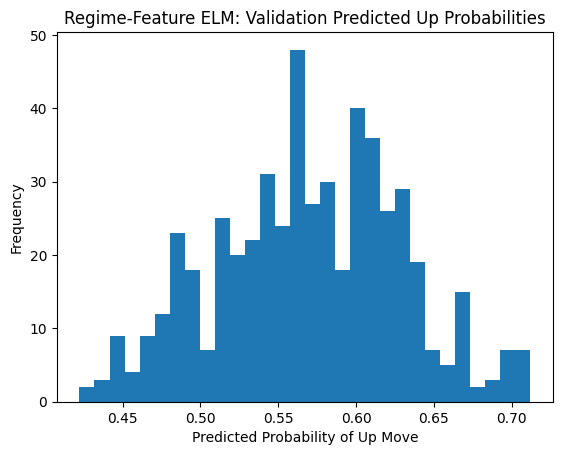

In [175]:
y_val_prob_2 = elm_regime_feature_model.predict_proba(X_val_2)

plt.hist(y_val_prob_2, bins=30)
plt.title("Regime-Feature ELM: Validation Predicted Up Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Frequency")
plt.show()

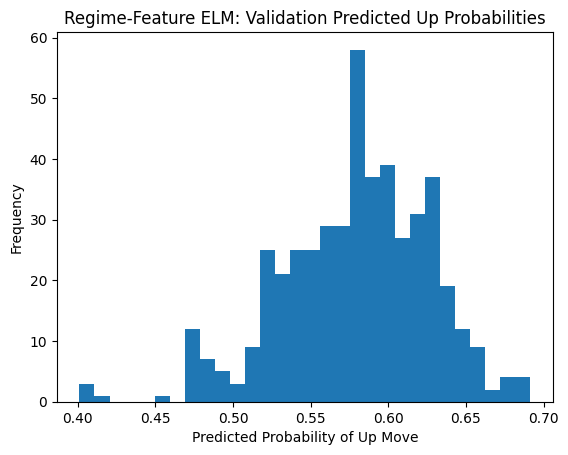

In [176]:
y_test_prob_2 = elm_regime_feature_model.predict_proba(X_test_2)

plt.hist(y_test_prob_2, bins=30)
plt.title("Regime-Feature ELM: Validation Predicted Up Probabilities")
plt.xlabel("Predicted Probability of Up Move")
plt.ylabel("Frequency")
plt.show()

The summary below checks the scale and distribution of the regime probability features used by the regime-feature ELM.

In [46]:
# train_df_2[["regime_prob_0", "regime_prob_1"]].describe()

val_df_2[["regime_prob_0", "regime_prob_1"]].describe()

# test_df_2[["regime_prob_0", "regime_prob_1"]].describe()

,regime_prob_0,regime_prob_1
count,5.280000e+02,5.280000e+02
mean,6.309761e-01,2.901684e-01
std,4.588631e-01,4.290779e-01
min,2.125111e-09,2.684933e-23
25%,1.042522e-02,4.727157e-09
50%,9.999728e-01,3.115194e-06
75%,9.999999e-01,8.510138e-01
max,1.000000e+00,9.999998e-01


The classification metrics below evaluate the regime-feature ELM on the validation set.

In [47]:
classification_report_simple(elm_val_preds_2)

{'accuracy': 0.5435606060606061,
 'precision': 0.5436241610738255,
 'recall': 0.8678571428571429,
 'f1': 0.6685006877579092,
 'roc_auc': 0.5495247695852534,
 'confusion_matrix': array([[ 44, 204],
        [ 37, 243]], dtype=int64)}

The regime-feature ELM validation predictions are converted into trading positions using the same validation strategy rule as the baseline ELM.

In [48]:
elm_val_strategy_2 = apply_probability_vol_strategy(elm_val_preds_2)

The table compares validation trading performance for the regime-feature ELM strategy against buy-and-hold.

In [162]:
metrics_2 = pd.DataFrame({
    "ELM Strategy Val": strategy_metrics(elm_val_strategy_2, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(elm_val_strategy_2, "buy_hold_return")
}).T

metrics_2

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Strategy Val,0.015828,0.007538,0.072419,0.104087,-0.110694,0.183948,0.183948,0.014287
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000


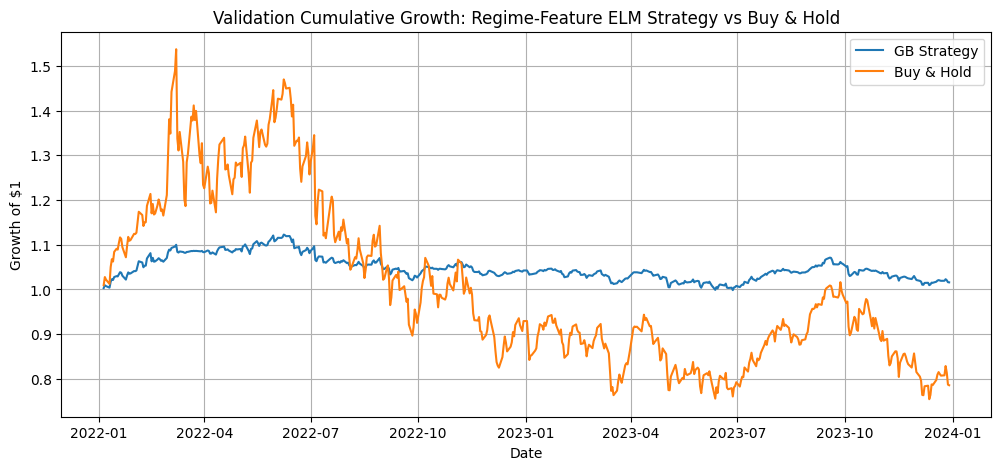

In [50]:
plot_df_2 = elm_val_strategy_2.dropna(subset=["net_strategy_return"]).copy()

plot_df_2["cum_strategy"] = (1 + plot_df_2["net_strategy_return"]).cumprod()
plot_df_2["cum_buy_hold"] = (1 + plot_df_2["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df_2["Date"], plot_df_2["cum_strategy"], label="GB Strategy")
plt.plot(plot_df_2["Date"], plot_df_2["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Validation Cumulative Growth: Regime-Feature ELM Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

This bucket analysis checks whether the regime-feature ELM's predicted probabilities are directionally meaningful across probability ranges.

In [51]:
val_bucket_2 = elm_val_preds_2.copy()

val_bucket_2["bucket"] = pd.cut(val_bucket_2["prob_up"], bins=10)

bucket_stats_2 = val_bucket_2.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

print(bucket_stats_2)

                 returns    Target   prob_up
bucket                                      
(0.422, 0.451] -0.002316  0.428571  0.439146
(0.451, 0.48]  -0.002371  0.560000  0.469437
(0.48, 0.509]  -0.002642  0.395833  0.490996
(0.509, 0.538]  0.002224  0.537313  0.523547
(0.538, 0.567] -0.001295  0.475728  0.553881
(0.567, 0.596]  0.002060  0.626667  0.580217
(0.596, 0.625] -0.001802  0.490196  0.609340
(0.625, 0.654]  0.000318  0.618182  0.635466
(0.654, 0.683]  0.000504  0.590909  0.667343
(0.683, 0.712]  0.008787  0.705882  0.699450


The comparison table summarizes validation trading performance across the baseline and regime-feature ELM versions.

In [163]:
comparison_metrics = pd.concat(
    {
        "baseline": metrics,
        "regime_feature": metrics_2
    }
)

comparison_metrics

Total Return      CAGR  Annual Vol    Sharpe  \
baseline       GB Strategy Val       0.071982  0.033796    0.160598  0.210440   
               Buy & Hold Val       -0.205251 -0.103846    0.406865 -0.255235   
regime_feature ELM Strategy Val      0.015828  0.007538    0.072419  0.104087   
               Buy & Hold Val       -0.205251 -0.103846    0.406865 -0.255235   

                                 Max Drawdown  Avg Position  Avg Abs Position  \
baseline       GB Strategy Val      -0.181644      0.370835          0.393763   
               Buy & Hold Val       -0.509424      1.000000          1.000000   
regime_feature ELM Strategy Val     -0.110694      0.183948          0.183948   
               Buy & Hold Val       -0.509424      1.000000          1.000000   

                                 Avg Turnover  
baseline       GB Strategy Val       0.042851  
               Buy & Hold Val        0.000000  
regime_feature ELM Strategy Val      0.014287  
               Buy & Hold Val        0.000000

The probability summary compares how the baseline and regime-feature ELM models distribute their predicted upward-move probabilities.

In [53]:
pd.DataFrame({
    "baseline_val": elm_val_preds["prob_up"].describe(),
    "regime_feature_val": elm_val_preds_2["prob_up"].describe()
})

,baseline_val,regime_feature_val
count,528.000000,528.000000
mean,0.755406,0.569642
std,0.208692,0.059875
min,0.083327,0.422335
25%,0.654572,0.528437
50%,0.775838,0.569053
75%,0.940592,0.612096
max,0.996914,0.711978


# Regime-Specific ELM Model

This section trains separate ELM classifiers within each lagged HMM regime. Instead of using one global ELM for all market environments, the regime-specific approach allows the relationship between predictors and WTI direction to differ across regimes.

The lagged regime label is used instead of the same-day regime label to avoid using regime information that would not have been known at the time the prediction was made.

## 18. Create Regime-Specific Modeling Copies

I create separate copies of the HMM-augmented train, validation, and test datasets for the regime-specific ELM workflow.

In [54]:
train_df_3 = train_df_2.copy()
val_df_3 = val_df_2.copy()
test_df_3 = test_df_2.copy()

## 19. Construct Lagged Regime Labels

The regime-specific ELM uses the previous day's regime label. This avoids look-ahead bias because the prediction for a given date should only use information known before that date's return is realized.

In [55]:
for df in [train_df_2, val_df_2, test_df_2]:
    df["regime_lag"] = df["regime"].shift(1)

In [57]:
train_df_3 = train_df_2.dropna().copy()
val_df_3 = val_df_2.dropna().copy()
test_df_3 = test_df_2.dropna().copy()

After shifting the regime label by one day, the first observation in each split has no previous regime. I drop only those rows rather than dropping all rows with any missing value.

In [59]:
train_df_3 = train_df_3.dropna(subset=["regime_lag"]).copy()
val_df_3 = val_df_3.dropna(subset=["regime_lag"]).copy()
test_df_3 = test_df_3.dropna(subset=["regime_lag"]).copy()

train_df_3["regime_lag"] = train_df_3["regime_lag"].astype(int)
val_df_3["regime_lag"] = val_df_3["regime_lag"].astype(int)
test_df_3["regime_lag"] = test_df_3["regime_lag"].astype(int)

## 20. Define Regime-Specific Feature Set

For the regime-specific ELM, the hard regime label and lagged regime label are not used as predictors. They are used only to split the data into separate regime-specific subsets. The HMM regime probabilities are also excluded because the purpose of this version is to train separate models by regime rather than provide regime probabilities to one global model.

In [60]:
target_col = "Target"

regime_specific_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_lag",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2",
]

feature_cols_3 = [c for c in train_df_3.columns if c not in regime_specific_exclude_cols]

print("Number of regime-specific features:", len(feature_cols_3))
print(feature_cols_3)

Number of regime-specific features: 42
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


## 21. Check Sample Size and Class Balance by Regime

Before fitting separate ELMs, I check how many observations are available in each lagged regime and whether both target classes appear. This matters because regime-specific models can become unstable if one regime has too few observations or if the target is highly imbalanced.

In [61]:
for r in sorted(train_df_3["regime_lag"].unique()):
    temp = train_df_3[train_df_3["regime_lag"] == r]
    print("Regime:", r)
    print("Rows:", len(temp))
    print(temp["Target"].value_counts())
    print()

Regime: 0
Rows: 662
Target
0    332
1    330
Name: count, dtype: int64

Regime: 1
Rows: 693
Target
1    381
0    312
Name: count, dtype: int64

Regime: 2
Rows: 386
Target
1    221
0    165
Name: count, dtype: int64



## 22. Train One ELM per Regime

A separate ELM classifier is trained within each lagged regime. If a regime contains only one target class, the notebook stores a fallback probability instead of fitting a classifier.

In [ ]:
models_by_regime = {}
fallback_prob_by_regime = {}

for r in sorted(train_df_3["regime_lag"].unique()):
    df_r = train_df_3[train_df_3["regime_lag"] == r].copy()

    X_r = df_r[feature_cols_3]
    y_r = df_r[target_col]

    print(f"Training regime {r}: {len(df_r)} rows")

    # fallback if only one class exists in that regime
    if y_r.nunique() < 2:
        fallback_prob_by_regime[r] = y_r.mean()
        models_by_regime[r] = None
        print(f"Regime {r} has one class only. Using fallback prob:", y_r.mean())
        continue

    model_r = ELMModel(
        n_hidden=100,
        activation="tanh",
        alpha=0.1,
        weight_init="normal",
        threshold=0.5,
        random_state=42
    )

    model_r.fit(X_r, y_r)

    models_by_regime[r] = model_r
    fallback_prob_by_regime[r] = y_r.mean()

Training regime 0: 662 rows
Training regime 1: 693 rows
Training regime 2: 386 rows


## 23. Generate Regime-Specific Predictions

This helper function applies the correct ELM to each observation based on its lagged regime. The output format matches the earlier model versions so classification and strategy metrics can be compared directly.

In [63]:
def make_regime_specific_predictions(df, feature_cols, models_by_regime, fallback_prob_by_regime, model_name, version, split_name):
    out = df[["Date", "Price", "returns", "vol_20", "Target", "regime", "regime_lag"]].copy()

    probs = []

    for idx, row in df.iterrows():
        r = int(row["regime_lag"])

        model_r = models_by_regime.get(r)

        if model_r is None:
            prob = fallback_prob_by_regime[r]
        else:
            X_row = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
            prob = model_r.predict_proba(X_row)[0]

        probs.append(prob)

    out["prob_up"] = probs
    out["pred"] = (out["prob_up"] >= 0.50).astype(int)
    out["model"] = model_name
    out["version"] = version
    out["split"] = split_name

    return out

In [64]:
elm_train_preds_3 = make_regime_specific_predictions(
    train_df_3,
    feature_cols_3,
    models_by_regime,
    fallback_prob_by_regime,
    "elm",
    "regime_specific",
    "train"
)

elm_val_preds_3 = make_regime_specific_predictions(
    val_df_3,
    feature_cols_3,
    models_by_regime,
    fallback_prob_by_regime,
    "elm",
    "regime_specific",
    "val"
)

elm_test_preds_3 = make_regime_specific_predictions(
    test_df_3,
    feature_cols_3,
    models_by_regime,
    fallback_prob_by_regime,
    "elm",
    "regime_specific",
    "test"
)

Saving the predictions to use for trading strategy tuning

In [65]:
elm_train_preds_3.to_csv("results/predictions/elm_regime_specific_train_predictions.csv", index=False)
elm_val_preds_3.to_csv("results/predictions/elm_regime_specific_val_predictions.csv", index=False)
elm_test_preds_3.to_csv("results/predictions/elm_regime_specific_test_predictions.csv", index=False)

Examining validaton set probabilities

In [66]:
elm_val_preds_3["prob_up"].describe()

count    527.000000
mean       0.361988
std        0.174422
min        0.055436
25%        0.206018
50%        0.349733
75%        0.464819
max        0.828280
Name: prob_up, dtype: float64

Classification report for validation set predictions

In [67]:
classification_report_simple(elm_val_preds_3)

{'accuracy': 0.4648956356736243,
 'precision': 0.48672566371681414,
 'recall': 0.1971326164874552,
 'f1': 0.28061224489795916,
 'roc_auc': 0.49656029598797546,
 'confusion_matrix': array([[190,  58],
        [224,  55]], dtype=int64)}

Examining how the trading results looked

In [178]:
elm_val_strategy_3 = apply_probability_vol_strategy(elm_val_preds_3)

metrics_3 = pd.DataFrame({
    "ELM Regime-Specific Strategy Val": strategy_metrics(elm_val_strategy_3, "net_strategy_return"),
    "Buy & Hold Val": strategy_metrics(elm_val_strategy_3, "buy_hold_return")
}).T

metrics_3

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Regime-Specific Strategy Val,-0.097938,-0.048181,0.075498,-0.638178,-0.115286,-0.022995,0.171849,0.029953
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.267671,-0.509424,1.000000,1.000000,0.000000


In [69]:
val_bucket_3 = elm_val_preds_3.copy()

val_bucket_3["bucket"] = pd.cut(val_bucket_3["prob_up"], bins=10)

bucket_stats_3 = val_bucket_3.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

bucket_stats_3

,returns,Target,prob_up
bucket,,,
"(0.0547, 0.133]",0.008718,0.590909,0.117569
"(0.133, 0.21]",-0.000993,0.535088,0.166732
"(0.21, 0.287]",0.001640,0.466667,0.249131
"(0.287, 0.365]",-0.001708,0.505618,0.327033
"(0.365, 0.442]",-0.002979,0.567010,0.399922
"(0.442, 0.519]",0.004938,0.650000,0.477325
"(0.519, 0.596]",-0.001220,0.419355,0.566831
"(0.596, 0.674]",0.003227,0.520833,0.638340
"(0.674, 0.751]",-0.005749,0.526316,0.710584


In [165]:
comparison_metrics = pd.concat({
    "baseline": metrics,
    "regime_feature": metrics_2,
    "regime_specific": metrics_3
})

comparison_metrics

Total Return      CAGR  \
baseline        GB Strategy Val                      0.071982  0.033796   
                Buy & Hold Val                      -0.205251 -0.103846   
regime_feature  ELM Strategy Val                     0.015828  0.007538   
                Buy & Hold Val                      -0.205251 -0.103846   
regime_specific GB Regime-Specific Strategy Val     -0.097938 -0.048181   
                Buy & Hold Val                      -0.214415 -0.108988   

                                                 Annual Vol    Sharpe  \
baseline        GB Strategy Val                    0.160598  0.210440   
                Buy & Hold Val                     0.406865 -0.255235   
regime_feature  ELM Strategy Val                   0.072419  0.104087   
                Buy & Hold Val                     0.406865 -0.255235   
regime_specific GB Regime-Specific Strategy Val    0.075498 -0.638178   
                Buy & Hold Val                     0.407170 -0.267671   

                                                 Max Drawdown  Avg Position  \
baseline        GB Strategy Val                     -0.181644      0.370835   
                Buy & Hold Val                      -0.509424      1.000000   
regime_feature  ELM Strategy Val                    -0.110694      0.183948   
                Buy & Hold Val                      -0.509424      1.000000   
regime_specific GB Regime-Specific Strategy Val     -0.115286     -0.022995   
                Buy & Hold Val                      -0.509424      1.000000   

                                                 Avg Abs Position  \
baseline        GB Strategy Val                          0.393763   
                Buy & Hold Val                           1.000000   
regime_feature  ELM Strategy Val                         0.183948   
                Buy & Hold Val                           1.000000   
regime_specific GB Regime-Specific Strategy Val          0.171849   
                Buy & Hold Val                           1.000000   

                                                 Avg Turnover  
baseline        GB Strategy Val                      0.042851  
                Buy & Hold Val                       0.000000  
regime_feature  ELM Strategy Val                     0.014287  
                Buy & Hold Val                       0.000000  
regime_specific GB Regime-Specific Strategy Val      0.029953  
                Buy & Hold Val                       0.000000

In [71]:
pd.DataFrame({
    "baseline": elm_val_preds["prob_up"].describe(),
    "regime_feature": elm_val_preds_2["prob_up"].describe(),
    "regime_specific": elm_val_preds_3["prob_up"].describe()
})

,baseline,regime_feature,regime_specific
count,528.000000,528.000000,527.000000
mean,0.755406,0.569642,0.361988
std,0.208692,0.059875,0.174422
min,0.083327,0.422335,0.055436
25%,0.654572,0.528437,0.206018
50%,0.775838,0.569053,0.349733
75%,0.940592,0.612096,0.464819
max,0.996914,0.711978,0.828280


In [73]:
elm_val_preds_3.groupby("regime_lag")["prob_up"].describe()

,count,mean,std,min,25%,50%,75%,max
regime_lag,,,,,,,,
0,324.0,0.325866,0.157399,0.103280,0.179978,0.304574,0.417366,0.702267
1,161.0,0.483256,0.150437,0.263911,0.351403,0.437923,0.608443,0.828280
2,42.0,0.175777,0.056859,0.055436,0.140216,0.162831,0.205296,0.305787


Classification reports for each regime model

In [74]:
for r in sorted(elm_val_preds_3["regime_lag"].unique()):
    temp = elm_val_preds_3[elm_val_preds_3["regime_lag"] == r]

    print(f"\nRegime {r}")
    print("Rows:", len(temp))
    print(classification_report_simple(temp))


Regime 0
Rows: 324
{'accuracy': 0.4691358024691358, 'precision': 0.43478260869565216, 'recall': 0.12048192771084337, 'f1': 0.18867924528301888, 'roc_auc': 0.5024782675003814, 'confusion_matrix': array([[132,  26],
       [146,  20]], dtype=int64)}

Regime 1
Rows: 161
{'accuracy': 0.4782608695652174, 'precision': 0.5223880597014925, 'recall': 0.40229885057471265, 'f1': 0.45454545454545453, 'roc_auc': 0.49565082323703014, 'confusion_matrix': array([[42, 32],
       [52, 35]], dtype=int64)}

Regime 2
Rows: 42
{'accuracy': 0.38095238095238093, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.44230769230769235, 'confusion_matrix': array([[16,  0],
       [26,  0]], dtype=int64)}


Looking at how each regime predicted probabilites and generated returns by bucket

In [75]:
for r in sorted(elm_val_preds_3["regime_lag"].unique()):
    temp = elm_val_preds_3[elm_val_preds_3["regime_lag"] == r].copy()

    temp["bucket"] = pd.cut(temp["prob_up"], bins=5)

    bucket_stats = temp.groupby("bucket", observed=False).agg({
        "returns": "mean",
        "Target": "mean",
        "prob_up": "mean"
    })

    print(f"\nRegime {r} bucket stats")
    print(bucket_stats)


Regime 0 bucket stats
                 returns    Target   prob_up
bucket                                      
(0.103, 0.223]  0.000307  0.521739  0.166889
(0.223, 0.343] -0.000087  0.439394  0.281522
(0.343, 0.463] -0.003062  0.576471  0.397849
(0.463, 0.582]  0.001950  0.518519  0.510764
(0.582, 0.702] -0.001590  0.451613  0.651617

Regime 1 bucket stats
                 returns    Target   prob_up
bucket                                      
(0.263, 0.377] -0.004146  0.491228  0.330607
(0.377, 0.49]   0.000757  0.656250  0.420307
(0.49, 0.603]   0.003691  0.551724  0.554652
(0.603, 0.715]  0.002144  0.555556  0.642066
(0.715, 0.828] -0.003644  0.437500  0.755572

Regime 2 bucket stats
                  returns    Target   prob_up
bucket                                       
(0.0552, 0.106]  0.045169  0.500000  0.079471
(0.106, 0.156]   0.003632  0.705882  0.134922
(0.156, 0.206]   0.002346  0.615385  0.180875
(0.206, 0.256]   0.015249  0.500000  0.225471
(0.256, 0.306]   0.003880

Comparing how each regime predicted probabilities

In [77]:
regime_summary = elm_val_preds_3.groupby("regime_lag").agg(
    rows=("prob_up", "count"),
    mean_prob=("prob_up", "mean"),
    std_prob=("prob_up", "std"),
    min_prob=("prob_up", "min"),
    max_prob=("prob_up", "max"),
    actual_up_rate=("Target", "mean"),
    avg_return=("returns", "mean")
)

regime_summary

,rows,mean_prob,std_prob,min_prob,max_prob,actual_up_rate,avg_return
regime_lag,,,,,,,
0,324,0.325866,0.157399,0.103280,0.702267,0.512346,-0.000702
1,161,0.483256,0.150437,0.263911,0.828280,0.540373,-0.000655
2,42,0.175777,0.056859,0.055436,0.305787,0.619048,0.006353


# Pre-COT ELM Baseline

This section trains an ELM after removing all CFTC/COT positioning variables. The purpose is to create a clean comparison between the original macro/price-based feature set and the COT-augmented models. This helps isolate whether the alternative COT dataset adds useful predictive or trading information.

## 24. Load and Align the Pre-COT Dataset

The pre-COT baseline uses the original train, validation, and test files before adding the COT-enhanced features. I align the dates to the current modeling splits so comparisons are made on the same sample period.

In [78]:
train_df_pre = pd.read_csv("train_final.csv")
val_df_pre = pd.read_csv("val_final.csv")
test_df_pre = pd.read_csv("test_final.csv")

for df in [train_df_pre, val_df_pre, test_df_pre]:
    df["Date"] = pd.to_datetime(df["Date"])
    df.sort_values("Date", inplace=True)
    df.reset_index(drop=True, inplace=True)

# align to your current baseline dates
train_df_pre = train_df_pre[train_df_pre["Date"].isin(train_df["Date"])].copy()
val_df_pre = val_df_pre[val_df_pre["Date"].isin(val_df["Date"])].copy()
test_df_pre = test_df_pre[test_df_pre["Date"].isin(test_df["Date"])].copy()

# overwrite returns from baseline to guarantee same buy & hold
def align_returns_to_base(df_new, df_base):
    df_new = df_new.drop(columns=["returns"], errors="ignore")
    out = df_new.merge(
        df_base[["Date", "returns"]],
        on="Date",
        how="left"
    )
    return out.sort_values("Date").reset_index(drop=True)

train_df_pre = align_returns_to_base(train_df_pre, train_df)
val_df_pre = align_returns_to_base(val_df_pre, val_df)
test_df_pre = align_returns_to_base(test_df_pre, test_df)

print(train_df_pre.shape, val_df_pre.shape, test_df_pre.shape)
print(train_df_pre["Date"].min(), train_df_pre["Date"].max())
print(val_df_pre["Date"].min(), val_df_pre["Date"].max())
print(test_df_pre["Date"].min(), test_df_pre["Date"].max())

(1742, 50) (528, 50) (474, 50)
2015-05-24 00:00:00 2021-12-31 00:00:00
2022-01-04 00:00:00 2023-12-29 00:00:00
2024-01-03 00:00:00 2025-10-31 00:00:00


## 25. Identify and Remove COT Features

To construct the pre-COT baseline, I identify columns associated with CFTC/COT positioning data and remove them from the predictor set.

In [79]:
cot_keywords = [
    "Open_Interest",
    "open_interest",
    "Producer",
    "Merchant",
    "Swap",
    "Money",
    "Other_Reportable",
    "Nonreportable",
    "long",
    "short",
    "Long",
    "Short",
    "net_position",
    "net_position_pct",
    "long_short_ratio",
    "flow",
    "oi_change"
]

cot_cols = [
    c for c in train_df_pre.columns
    if any(keyword in c for keyword in cot_keywords)
]

print("COT columns removed:")
print(cot_cols)
print("Number removed:", len(cot_cols))

COT columns removed:
['net_position', 'net_position_pct', 'flow', 'long_short_ratio', 'Open_Interest_All', 'oi_change']
Number removed: 6


## 26. Define Pre-COT Feature Set

The pre-COT model excludes date fields, prices, realized returns, target labels, regime features, and all COT-related variables. This leaves the macroeconomic and price-derived predictors available before the alternative COT dataset was introduced.

In [80]:
target_col = "Target"

pre_cot_exclude_cols = [
    "Date",
    "Price",
    "returns",
    "Target",
    "regime",
    "regime_prob_0",
    "regime_prob_1",
    "regime_prob_2"
] + cot_cols

feature_cols_pre = [
    c for c in train_df_pre.columns
    if c not in pre_cot_exclude_cols
]

print("Pre-COT feature count:", len(feature_cols_pre))
print(feature_cols_pre)

Pre-COT feature count: 36
['RPI', 'W875RX1', 'CMRMTSPLx', 'IPFPNSS', 'USWTRADE', 'USTRADE', 'BUSLOANS', 'CONSPI', 'S&P 500', 'S&P PE ratio', 'FEDFUNDS', 'TB3MS', 'TB6MS', 'GS1', 'GS5', 'GS10', 'AAA', 'BAA', 'TB3SMFFM', 'TB6SMFFM', 'T1YFFM', 'T5YFFM', 'T10YFFM', 'AAAFFM', 'BAAFFM', 'EXSZUSx', 'EXJPUSx', 'EXUSUKx', 'EXCAUSx', 'PPICMM', 'UMCSENTx', 'vol_20', 'momentum_20', 'vol_60', 'drawdown', 'trend']


The predictors and target are split into train, validation, and test matrices for the pre-COT ELM.

In [81]:
X_train_pre = train_df_pre[feature_cols_pre].copy()
y_train_pre = train_df_pre[target_col].copy()

X_val_pre = val_df_pre[feature_cols_pre].copy()
y_val_pre = val_df_pre[target_col].copy()

X_test_pre = test_df_pre[feature_cols_pre].copy()
y_test_pre = test_df_pre[target_col].copy()

## 27. Tune the Pre-COT ELM

The pre-COT ELM is tuned using the same time-series cross-validation procedure as the other ELM versions.

In [82]:
best_params_pre, best_cv_score_pre, cv_results_pre = tune_elm(
    X_train_pre,
    y_train_pre,
    n_splits=5
)

print("Best params:", best_params_pre) 
print("Best CV ROC-AUC:", best_cv_score_pre)

cv_results_pre.head(10)

Best params: {'activation': 'tanh', 'alpha': 0.01, 'n_hidden': 100, 'weight_init': 'xavier'}
Best CV ROC-AUC: 0.5278991289951225


,activation,alpha,n_hidden,weight_init,mean_cv_roc_auc
4,tanh,0.01,100,xavier,0.527899
113,relu,0.01,100,normal,0.525934
149,relu,1.00,100,normal,0.525917
131,relu,0.10,100,normal,0.525395
157,relu,1.00,400,xavier,0.524536
40,tanh,1.00,100,xavier,0.524174
60,sigmoid,0.01,200,orthogonal,0.523690
120,relu,0.01,400,orthogonal,0.522979
31,tanh,0.10,400,xavier,0.522255
139,relu,0.10,400,xavier,0.522078


## 28. Fit the Pre-COT ELM

Using the selected hyperparameters, I fit the pre-COT ELM on the training data.

In [84]:
elm_pre_cot_model = ELMModel(
    activation=best_params_pre["activation"],
    alpha=best_params_pre["alpha"],
    n_hidden=best_params_pre["n_hidden"],
    weight_init=best_params_pre["weight_init"],
    threshold=0.50,
    random_state=42
)

elm_pre_cot_model.fit(X_train_pre, y_train_pre)

## 29. Generate Pre-COT Predictions

Predictions are generated in the same format as the other ELM versions so classification and strategy results can be compared directly.

In [85]:
elm_train_preds_pre = make_prediction_output(
    train_df_pre,
    X_train_pre,
    y_train_pre,
    elm_pre_cot_model,
    "elm",
    "pre_cot_baseline",
    "train"
)

elm_val_preds_pre = make_prediction_output(
    val_df_pre,
    X_val_pre,
    y_val_pre,
    elm_pre_cot_model,
    "elm",
    "pre_cot_baseline",
    "val"
)

elm_test_preds_pre = make_prediction_output(
    test_df_pre,
    X_test_pre,
    y_test_pre,
    elm_pre_cot_model,
    "elm",
    "pre_cot_baseline",
    "test"
)

The pre-COT prediction files are saved for later comparison.

In [86]:
elm_train_preds_pre.to_csv(
    "results/predictions/elm_pre_cot_baseline_train_predictions.csv",
    index=False
)

elm_val_preds_pre.to_csv(
    "results/predictions/elm_pre_cot_baseline_val_predictions.csv",
    index=False
)

elm_test_preds_pre.to_csv(
    "results/predictions/elm_pre_cot_baseline_test_predictions.csv",
    index=False
)

The summary below checks the distribution of pre-COT validation predictions.

In [87]:
elm_val_preds_pre[["prob_up", "pred", "Target", "returns", "vol_20"]].describe()

,prob_up,pred,Target,returns,vol_20
count,528.000000,528.000000,528.000000,528.000000,528.000000
mean,0.767023,0.882576,0.530303,-0.000103,0.024159
std,0.169417,0.322230,0.499554,0.025630,0.008671
min,0.360848,0.000000,0.000000,-0.134360,0.008609
25%,0.689754,1.000000,0.000000,-0.015055,0.018637
50%,0.812737,1.000000,1.000000,0.001782,0.022686
75%,0.892384,1.000000,1.000000,0.016680,0.027254
max,0.987480,1.000000,1.000000,0.082612,0.055159


The summary below checks the distribution of pre-COT validation predictions.

In [88]:
classification_report_simple(elm_val_preds_pre)

{'accuracy': 0.5265151515151515,
 'precision': 0.5321888412017167,
 'recall': 0.8857142857142857,
 'f1': 0.6648793565683646,
 'roc_auc': 0.5111319124423962,
 'confusion_matrix': array([[ 30, 218],
        [ 32, 248]], dtype=int64)}

In [89]:
classification_report_simple(elm_test_preds_pre)

{'accuracy': 0.510548523206751,
 'precision': 0.5092936802973977,
 'recall': 0.5780590717299579,
 'f1': 0.541501976284585,
 'roc_auc': 0.5155690861507236,
 'confusion_matrix': array([[105, 132],
        [100, 137]], dtype=int64)}

The pre-COT validation predictions are converted into trading positions using the same strategy rules as the other ELM versions.

In [166]:
elm_val_strategy_pre = apply_probability_vol_strategy(elm_val_preds_pre)

metrics_pre = pd.DataFrame({
    "ELM Pre-COT Baseline Strategy Val": strategy_metrics(
        elm_val_strategy_pre,
        "net_strategy_return"
    ),
    "Buy & Hold Val": strategy_metrics(
        elm_val_strategy_pre,
        "buy_hold_return"
    )
}).T

metrics_pre

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Pre-COT Baseline Strategy Val,-0.044050,-0.021311,0.164298,-0.129712,-0.239030,0.37758,0.379212,0.02152
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.00000,1.000000,0.00000


The pre-COT validation predictions are converted into trading positions using the same strategy rules as the other ELM versions.

In [179]:
elm_baseline_comparison = pd.concat([
    metrics_pre,
    metrics, 
    metrics_2, 
    metrics_3
])

elm_baseline_comparison

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Pre-COT Baseline Strategy Val,-0.044050,-0.021311,0.164298,-0.129712,-0.239030,0.377580,0.379212,0.021520
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000
ELM Strategy Val,0.071982,0.033796,0.160598,0.210440,-0.181644,0.370835,0.393763,0.042851
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000
ELM Strategy Val,0.015828,0.007538,0.072419,0.104087,-0.110694,0.183948,0.183948,0.014287
Buy & Hold Val,-0.205251,-0.103846,0.406865,-0.255235,-0.509424,1.000000,1.000000,0.000000
ELM Regime-Specific Strategy Val,-0.097938,-0.048181,0.075498,-0.638178,-0.115286,-0.022995,0.171849,0.029953
Buy & Hold Val,-0.214415,-0.108988,0.407170,-0.267671,-0.509424,1.000000,1.000000,0.000000


The pre-COT bucket analysis checks whether its predicted probabilities are directionally meaningful across probability ranges.

In [92]:
val_bucket_pre = elm_val_preds_pre.copy()

val_bucket_pre["bucket"] = pd.cut(val_bucket_pre["prob_up"], bins=10)

bucket_stats_pre = val_bucket_pre.groupby("bucket", observed=False).agg({
    "returns": "mean",
    "Target": "mean",
    "prob_up": "mean"
})

bucket_stats_pre

,returns,Target,prob_up
bucket,,,
"(0.36, 0.424]",0.001445,0.473684,0.392640
"(0.424, 0.486]",-0.001806,0.578947,0.450403
"(0.486, 0.549]",-0.001753,0.727273,0.500528
"(0.549, 0.612]",0.004771,0.571429,0.581083
"(0.612, 0.674]",-0.002407,0.545455,0.629603
"(0.674, 0.737]",0.002653,0.500000,0.710961
"(0.737, 0.799]",-0.004695,0.520000,0.770137
"(0.799, 0.862]",0.001895,0.558824,0.836566
"(0.862, 0.925]",-0.000939,0.500000,0.893306


# Final ELM Test Runs

After comparing model versions on the validation period, I perform final test evaluation. Each final ELM version is retrained on the combined train and validation data, then evaluated once on the held-out test set.

The same trading-strategy parameters are applied to all final ELM versions so that differences in performance come from the model predictions rather than from model-specific strategy tuning.

# Final ELM Test Runs

After comparing model versions on the validation period, I perform final test evaluation. Each final ELM version is retrained on the combined train and validation data, then evaluated once on the held-out test set.

The same trading-strategy parameters are applied to all final ELM versions so that differences in performance come from the model predictions rather than from model-specific strategy tuning.

In [98]:
def apply_probability_vol_strategy_tuned(
    preds,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    target_annual_vol=0.28,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    max_position=1.0
):
    df = preds.copy()

    prob = df["prob_up"]

    raw_signal = np.zeros(len(df))

    long_mask = prob >= long_threshold
    short_mask = prob <= short_threshold

    raw_signal[long_mask] = signal_multiplier * (prob[long_mask] - long_threshold)
    raw_signal[short_mask] = signal_multiplier * (prob[short_mask] - short_threshold)

    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    target_daily_vol = target_annual_vol / np.sqrt(252)
    adjusted_vol = df[vol_col].clip(lower=vol_floor)
    
    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)
    df["position"] = df["position"].clip(-max_position, max_position)

    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]
    df["net_strategy_return"] = (
        df["gross_strategy_return"] - transaction_cost * df["turnover"]
    )

    df["buy_hold_return"] = df["returns"]

    return df

## 31. Final Test Run: Pre-COT ELM

The pre-COT ELM is retrained on the combined train and validation periods using the selected hyperparameters, then evaluated on the held-out test set.

In [168]:
trainval_df_pre = pd.concat([train_df_pre, val_df_pre], axis=0).copy()
trainval_df_pre["Date"] = pd.to_datetime(trainval_df_pre["Date"])
test_df_pre["Date"] = pd.to_datetime(test_df_pre["Date"])

trainval_df_pre = trainval_df_pre.sort_values("Date").reset_index(drop=True)
test_df_pre = test_df_pre.sort_values("Date").reset_index(drop=True)

X_trainval_pre = trainval_df_pre[feature_cols_pre].copy()
y_trainval_pre = trainval_df_pre["Target"].copy()

X_test_pre_final = test_df_pre[feature_cols_pre].copy()
y_test_pre_final = test_df_pre["Target"].copy()

elm_pre_cot_final_model = ELMModel(
    n_hidden=best_params_pre["n_hidden"],
    activation=best_params_pre["activation"],
    alpha=best_params_pre["alpha"],
    weight_init=best_params_pre["weight_init"],
    threshold=0.5,
    random_state=42
)

elm_pre_cot_final_model.fit(X_trainval_pre, y_trainval_pre)

elm_test_preds_pre_final = make_prediction_output(
    test_df_pre,
    X_test_pre_final,
    y_test_pre_final,
    elm_pre_cot_final_model,
    "elm",
    "pre_cot_baseline_final_trainval",
    "test"
)

elm_test_preds_pre_final.to_csv(
    "results/final_test_predictions/elm_pre_cot_baseline_final_test_predictions.csv",
    index=False
)

classification_report_simple(elm_test_preds_pre_final)

elm_test_strategy_pre_final = apply_probability_vol_strategy_tuned(
    elm_test_preds_pre_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

elm_pre_final_test_metrics = pd.DataFrame({
    "ELM Pre-COT Final Test Strategy": strategy_metrics(
        elm_test_strategy_pre_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        elm_test_strategy_pre_final,
        "buy_hold_return"
    )
}).T

elm_pre_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Pre-COT Final Test Strategy,-0.181236,-0.101054,0.244223,-0.413777,-0.292916,0.562904,0.709199,0.047969
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000


The classification report below evaluates the final pre-COT ELM's directional accuracy on the held-out test set.

In [101]:
classification_report_simple(elm_test_strategy_pre_final)

{'accuracy': 0.5021097046413502,
 'precision': 0.5013850415512465,
 'recall': 0.7637130801687764,
 'f1': 0.6053511705685619,
 'roc_auc': 0.5012017304919083,
 'confusion_matrix': array([[ 57, 180],
        [ 56, 181]], dtype=int64)}

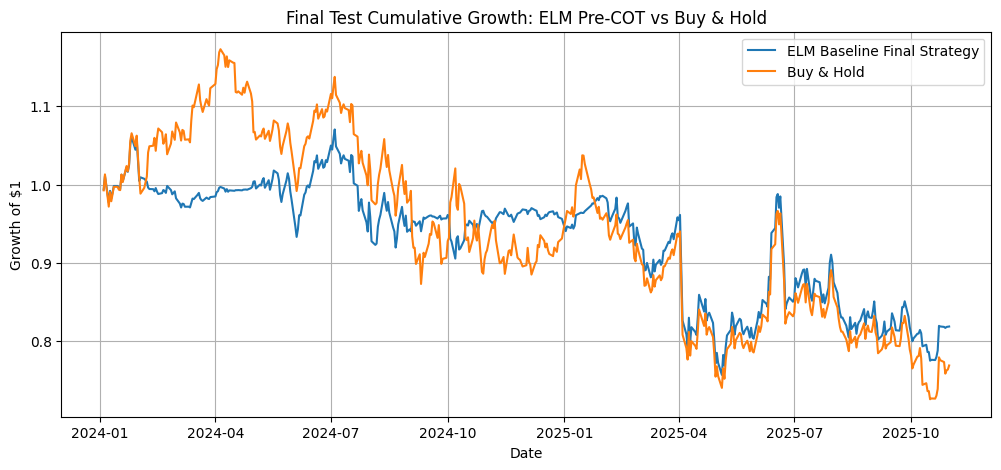

In [181]:
plot_df = elm_test_strategy_pre_final.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="ELM Baseline Final Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: ELM Pre-COT vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 32. Final Test Run: COT-Augmented Baseline ELM

This final model uses the COT-augmented feature set but does not include HMM regime features. It is retrained on train plus validation data and evaluated on the held-out test set.

In [169]:
trainval_df = pd.concat([train_df, val_df], axis=0).copy()
trainval_df["Date"] = pd.to_datetime(trainval_df["Date"])
test_df["Date"] = pd.to_datetime(test_df["Date"])

trainval_df = trainval_df.sort_values("Date").reset_index(drop=True)
test_df = test_df.sort_values("Date").reset_index(drop=True)

X_trainval = trainval_df[feature_cols].copy()
y_trainval = trainval_df["Target"].copy()

X_test_final = test_df[feature_cols].copy()
y_test_final = test_df["Target"].copy()

elm_baseline_final_model = ELMModel(
    n_hidden=200,
    activation="relu",
    alpha=0.01,
    weight_init="xavier",
    threshold=0.5,
    random_state=42
)

elm_baseline_final_model.fit(X_trainval, y_trainval)

elm_test_preds_final = make_prediction_output(
    test_df,
    X_test_final,
    y_test_final,
    elm_baseline_final_model,
    "elm",
    "baseline_final_trainval",
    "test"
)

elm_test_preds_final.to_csv(
    "results/final_test_predictions/elm_baseline_final_test_predictions.csv",
    index=False
)

classification_report_simple(elm_test_preds_final)

elm_test_strategy_final = apply_probability_vol_strategy_tuned(
    elm_test_preds_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

elm_final_test_metrics = pd.DataFrame({
    "ELM Baseline Final Test Strategy": strategy_metrics(
        elm_test_strategy_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        elm_test_strategy_final,
        "buy_hold_return"
    )
}).T

elm_final_test_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Baseline Final Test Strategy,-0.126821,-0.069703,0.274841,-0.253611,-0.304462,0.775148,0.884825,0.042673
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000


In [134]:
classification_report_simple(elm_test_strategy_final)

{'accuracy': 0.4936708860759494,
 'precision': 0.4968017057569296,
 'recall': 0.9831223628691983,
 'f1': 0.660056657223796,
 'roc_auc': 0.5189161281133722,
 'confusion_matrix': array([[  1, 236],
        [  4, 233]], dtype=int64)}

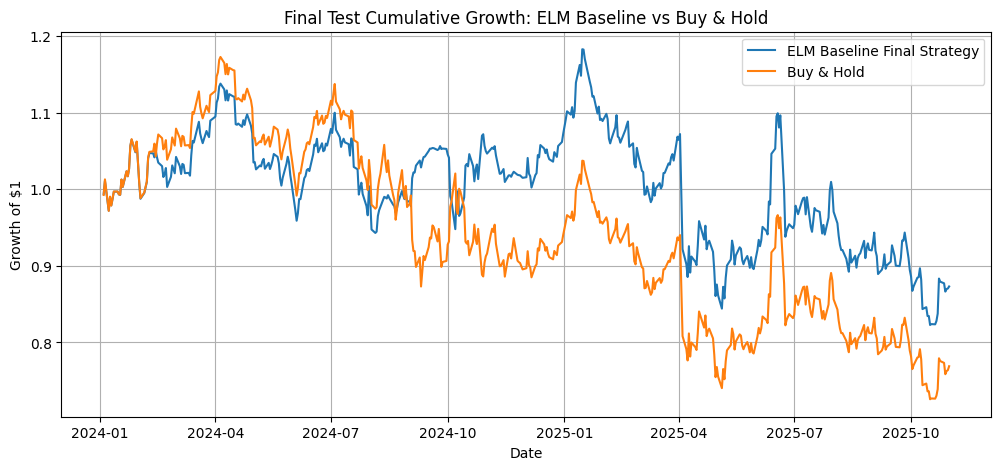

In [182]:
plot_df = elm_test_strategy_final.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="ELM Baseline Final Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: ELM Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 33. Final Test Run: Regime-Feature ELM

The regime-feature ELM uses the HMM regime probabilities as additional predictors in one global ELM classifier. It is retrained on train plus validation data and evaluated on the held-out test set.

In [170]:
trainval_df_2 = pd.concat([train_df_2, val_df_2], axis=0).copy()
trainval_df_2["Date"] = pd.to_datetime(trainval_df_2["Date"])
test_df_2["Date"] = pd.to_datetime(test_df_2["Date"])

trainval_df_2 = trainval_df_2.sort_values("Date").reset_index(drop=True)
test_df_2 = test_df_2.sort_values("Date").reset_index(drop=True)

X_trainval_2 = trainval_df_2[feature_cols].copy()
y_trainval_2 = trainval_df_2["Target"].copy()

X_test_2_final = test_df_2[feature_cols].copy()
y_test_2_final = test_df_2["Target"].copy()

print("Regime-feature ELM feature count:", len(feature_cols))
print("Regime prob columns used:", [c for c in feature_cols if "regime_prob" in c])

elm_regime_feature_final_model = ELMModel(
    n_hidden=100,
    activation="tanh",
    alpha=0.1,
    weight_init="normal",
    threshold=0.5,
    random_state=42
)

elm_regime_feature_final_model.fit(X_trainval_2, y_trainval_2)

elm_test_preds_2_final = make_prediction_output(
    test_df_2,
    X_test_2_final,
    y_test_2_final,
    elm_regime_feature_final_model,
    "elm",
    "regime_feature_final_trainval",
    "test"
)

elm_test_preds_2_final.to_csv(
    "results/final_test_predictions/elm_regime_feature_final_test_predictions.csv",
    index=False
)

classification_report_simple(elm_test_preds_2_final)

elm_test_strategy_2_final = apply_probability_vol_strategy_tuned(
    elm_test_preds_2_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

elm_2_final_test_metrics = pd.DataFrame({
    "ELM Regime-Feature Final Test Strategy": strategy_metrics(
        elm_test_strategy_2_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        elm_test_strategy_2_final,
        "buy_hold_return"
    )
}).T

elm_2_final_test_metrics

Regime-feature ELM feature count: 44
Regime prob columns used: ['regime_prob_0', 'regime_prob_1']


,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Regime-Feature Final Test Strategy,-0.081277,-0.044158,0.228183,-0.193522,-0.328124,0.680157,0.712873,0.050086
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000


In [146]:
classification_report_simple(elm_test_strategy_2_final)

{'accuracy': 0.5210970464135021,
 'precision': 0.5116279069767442,
 'recall': 0.9282700421940928,
 'f1': 0.6596701649175413,
 'roc_auc': 0.511972796382346,
 'confusion_matrix': array([[ 27, 210],
        [ 17, 220]], dtype=int64)}

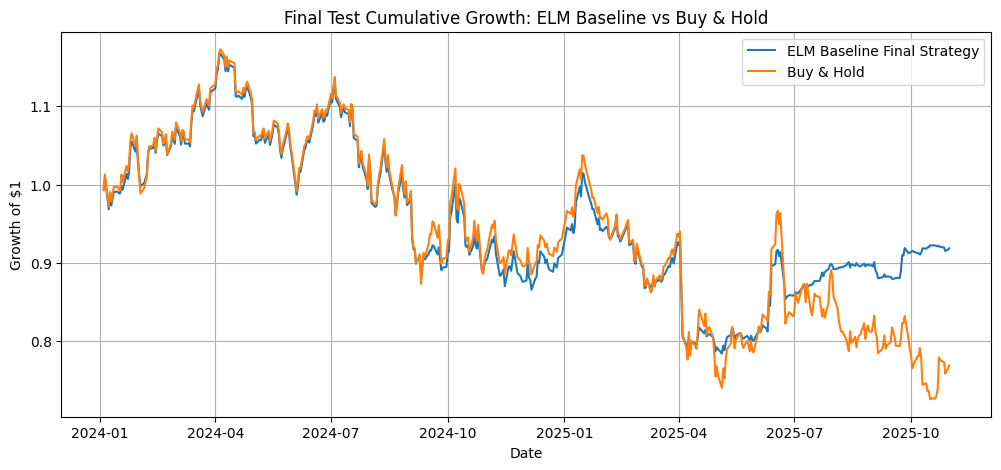

In [183]:
plot_df = elm_test_strategy_2_final.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="ELM Baseline Final Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: ELM Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 34. Final Test Run: Regime-Specific ELM

The regime-specific ELM trains separate classifiers within each lagged HMM regime using the combined train and validation data. Final test predictions are generated by applying the ELM corresponding to each observation's lagged regime.

In [148]:
trainval_df_3 = pd.concat([train_df_3, val_df_3], axis=0).copy()
trainval_df_3["Date"] = pd.to_datetime(trainval_df_3["Date"])
test_df_3["Date"] = pd.to_datetime(test_df_3["Date"])

trainval_df_3 = trainval_df_3.sort_values("Date").reset_index(drop=True)
test_df_3 = test_df_3.sort_values("Date").reset_index(drop=True)

print("Train+Val regimes:")
print(trainval_df_3["regime_lag"].value_counts())

print("\nTest regimes:")
print(test_df_3["regime_lag"].value_counts())

print("\nRegime-specific feature count:", len(feature_cols_3))
print("Regime prob columns included:", [c for c in feature_cols_3 if "regime_prob" in c])

Train+Val regimes:
regime_lag
0    986
1    854
2    428
Name: count, dtype: int64

Test regimes:
regime_lag
0    349
1    124
Name: count, dtype: int64

Regime-specific feature count: 42
Regime prob columns included: []


In [150]:
elm_regime_models_final = {}

for regime in sorted(trainval_df_3["regime_lag"].unique()):
    print(f"\nTraining final ELM model for regime {regime}")

    trainval_r = trainval_df_3[trainval_df_3["regime_lag"] == regime].copy()

    X_trainval_r = trainval_r[feature_cols_3].copy()
    y_trainval_r = trainval_r["Target"].copy()

    print("Rows:", len(trainval_r))
    print("X shape:", X_trainval_r.shape)

    model_r = ELMModel(
        n_hidden=100,
        activation="tanh",
        alpha=0.1,
        weight_init="normal",
        threshold=0.5,
        random_state=42
    )

    model_r.fit(X_trainval_r, y_trainval_r)

    elm_regime_models_final[regime] = model_r


Training final ELM model for regime 0
Rows: 986
X shape: (986, 42)

Training final ELM model for regime 1
Rows: 854
X shape: (854, 42)

Training final ELM model for regime 2
Rows: 428
X shape: (428, 42)


In [154]:
def make_regime_specific_elm_predictions_final(
    df,
    feature_cols,
    regime_models,
    model_name="elm",
    version="regime_specific_final_trainval",
    split_name="test"
):
    pred_list = []

    for regime, model in regime_models.items():
        df_r = df[df["regime_lag"] == regime].copy()

        if len(df_r) == 0:
            print(f"No rows for regime {regime}")
            continue

        X_r = df_r[feature_cols].copy()
        y_r = df_r["Target"].copy()

        preds_r = make_prediction_output(
            df_r,
            X_r,
            y_r,
            model,
            model_name,
            version,
            split_name
        )

        preds_r["regime_lag"] = regime
        pred_list.append(preds_r)

    out = pd.concat(pred_list, ignore_index=True)
    out = out.sort_values("Date").reset_index(drop=True)

    return out

In [171]:
elm_test_preds_3_final = make_regime_specific_elm_predictions_final(
    test_df_3,
    feature_cols_3,
    elm_regime_models_final,
    model_name="elm",
    version="regime_specific_final_trainval",
    split_name="test"
)

elm_test_preds_3_final.to_csv(
    "results/final_test_predictions/elm_regime_specific_final_test_predictions.csv",
    index=False
)

classification_report_simple(elm_test_preds_3_final)

elm_test_strategy_3_final = apply_probability_vol_strategy_tuned(
    elm_test_preds_3_final,
    signal_multiplier=3.5,
    long_threshold=0.50,
    short_threshold=0.50,
    alpha=3.0,
    beta=1.55,
    gamma=0.7,
    target_annual_vol=0.28
)

elm_3_final_test_metrics = pd.DataFrame({
    "ELM Regime-Specific Final Test Strategy": strategy_metrics(
        elm_test_strategy_3_final,
        "net_strategy_return"
    ),
    "Buy & Hold Final Test": strategy_metrics(
        elm_test_strategy_3_final,
        "buy_hold_return"
    )
}).T

elm_3_final_test_metrics

No rows for regime 2


,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Regime-Specific Final Test Strategy,-0.156142,-0.086654,0.272766,-0.317687,-0.340180,0.853144,0.867987,0.057369
Buy & Hold Final Test,-0.230993,-0.130585,0.298687,-0.437197,-0.381141,1.000000,1.000000,0.000000


In [156]:
classification_report_simple(elm_test_strategy_3_final)

{'accuracy': 0.5031712473572939,
 'precision': 0.5021739130434782,
 'recall': 0.9746835443037974,
 'f1': 0.6628407460545194,
 'roc_auc': 0.5239934205821355,
 'confusion_matrix': array([[  7, 229],
        [  6, 231]], dtype=int64)}

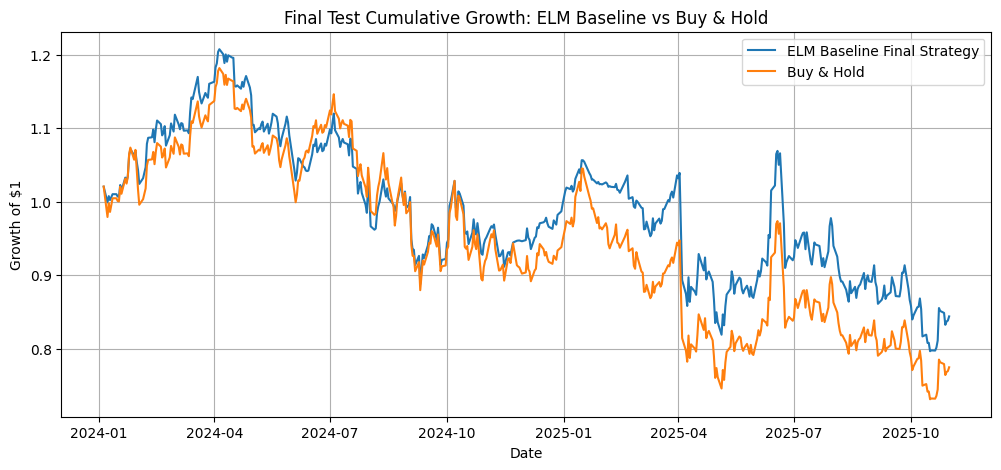

In [184]:
plot_df = elm_test_strategy_3_final.dropna(subset=["net_strategy_return"]).copy()

plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_df["Date"], plot_df["cum_strategy"], label="ELM Baseline Final Strategy")
plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
plt.legend()
plt.title("Final Test Cumulative Growth: ELM Baseline vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

## 35. Final ELM Comparison

The table below combines final test-period strategy metrics for all ELM versions: pre-COT, COT-augmented baseline, regime-feature, and regime-specific.

In [172]:
elm_final_test_all_metrics = pd.concat([
    elm_pre_final_test_metrics,
    elm_final_test_metrics,
    elm_2_final_test_metrics,
    elm_3_final_test_metrics
])

elm_final_test_all_metrics

,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
ELM Pre-COT Final Test Strategy,-0.181236,-0.101054,0.244223,-0.413777,-0.292916,0.562904,0.709199,0.047969
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000
ELM Baseline Final Test Strategy,-0.126821,-0.069703,0.274841,-0.253611,-0.304462,0.775148,0.884825,0.042673
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000
ELM Regime-Feature Final Test Strategy,-0.081277,-0.044158,0.228183,-0.193522,-0.328124,0.680157,0.712873,0.050086
Buy & Hold Final Test,-0.206663,-0.115807,0.299283,-0.386948,-0.381141,1.000000,1.000000,0.000000
ELM Regime-Specific Final Test Strategy,-0.156142,-0.086654,0.272766,-0.317687,-0.340180,0.853144,0.867987,0.057369
Buy & Hold Final Test,-0.230993,-0.130585,0.298687,-0.437197,-0.381141,1.000000,1.000000,0.000000


The final ELM metrics are saved so they can be used in the paper and compared with the other model families.

In [159]:
elm_final_test_all_metrics.to_csv(
    "results/final_test_predictions/elm_final_test_metrics.csv"
)